# Sélection de 2 000 highly variable genes

Sélection descriptive à partir des counts bruts des singlets de GSE149689, sans normalisation ni analyse en aval.

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import skmisc
from scipy import sparse
from IPython.display import Markdown, display

## Chargement et vérification des counts bruts

In [10]:
adata = sc.read_h5ad("../data/processed/GSE149689_singlets.h5ad")
figure_dir = Path("../results/figures/hvg")
figure_dir.mkdir(parents=True, exist_ok=True)

x_is_sparse = sparse.issparse(adata.X)
if not x_is_sparse:
    raise AssertionError("adata.X doit être une matrice sparse.")
x_values = adata.X.data
checks_before = {
    "20_sample_id_present": "sample_id" in adata.obs and adata.obs["sample_id"].nunique() == 20,
    "X_is_sparse": x_is_sparse,
    "counts_nonnegative": bool(np.all(x_values >= 0)),
    "counts_integer_valued": bool(np.all(np.equal(x_values, np.floor(x_values)))),
    "no_log1p_metadata": "log1p" not in adata.uns,
}
print(adata)
print("Dimensions :", adata.shape)
print("Nombre de sample_id :", adata.obs["sample_id"].nunique())
display(pd.Series(checks_before, name="passed").to_frame())
if not all(checks_before.values()):
    raise AssertionError(f"Échec des contrôles avant transformation : {checks_before}")

adata.layers["counts"] = adata.X.copy()
print("Counts bruts préservés dans adata.layers['counts'] :", adata.layers["counts"].shape)

AnnData object with n_obs × n_vars = 58825 × 33538
    obs: 'sample_id', 'subject_id', 'disease', 'severity', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
Dimensions : (58825, 33538)
Nombre de sample_id : 20


,passed
20_sample_id_present,True
X_is_sparse,True
counts_nonnegative,True
counts_integer_valued,True
no_log1p_metadata,True


Counts bruts préservés dans adata.layers['counts'] : (58825, 33538)


## Sélection des HVG avec seurat_v3

In [11]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3",
    batch_key="sample_id",
    layer="counts",
    inplace=True,
)
required_hvg_columns = {
    "highly_variable", "highly_variable_rank", "highly_variable_nbatches",
    "means", "variances", "variances_norm",
}
missing_hvg_columns = required_hvg_columns.difference(adata.var.columns)
if missing_hvg_columns:
    raise AssertionError(f"Colonnes HVG manquantes : {sorted(missing_hvg_columns)}")
if int(adata.var["highly_variable"].sum()) != 2000:
    raise AssertionError("La sélection n'a pas produit exactement 2 000 HVG.")
top_hvg = (
    adata.var.loc[adata.var["highly_variable"], [
        "highly_variable", "highly_variable_rank", "highly_variable_nbatches",
        "means", "variances", "variances_norm",
    ]]
    .sort_values("highly_variable_rank")
    .head(30)
    .rename_axis("gene_name")
    .reset_index()
)
display(top_hvg)

,gene_name,highly_variable,highly_variable_rank,highly_variable_nbatches,means,variances,variances_norm
0,PTGDS,True,4.0,19,0.400153,16.593598,10.463051
1,STMN1,True,6.0,20,0.495538,18.617589,9.321393
2,IGKC,True,8.0,20,15.973617,169157.652847,9.638552
3,IGLC3,True,9.0,19,2.665108,19947.157158,8.998228
4,IGLC2,True,11.0,19,5.938870,41080.940843,9.568086
5,LYPD2,True,13.5,12,0.120663,3.569250,4.705871
6,HBA2,True,14.0,18,10.595767,8549.956561,9.658658
7,TYMS,True,14.0,19,0.170489,4.022936,7.426930
8,C1QA,True,15.0,20,0.232775,8.852639,8.155299
9,PPBP,True,15.0,19,3.461062,303.309348,8.288595


## Reproductibilité des HVG entre échantillons

,n_samples,n_hvg
0,1,488
1,2,125
2,3,87
3,4,46
4,5,64
5,6,48
6,7,56
7,8,68
8,9,58
9,10,66


,value
Q1_highly_variable_nbatches,2.0
median_highly_variable_nbatches,9.0
Q3_highly_variable_nbatches,16.0
HVG_in_at_least_5_samples,1254.0
HVG_in_at_least_10_samples,960.0
HVG_in_at_least_15_samples,644.0
HVG_in_all_20_samples,103.0


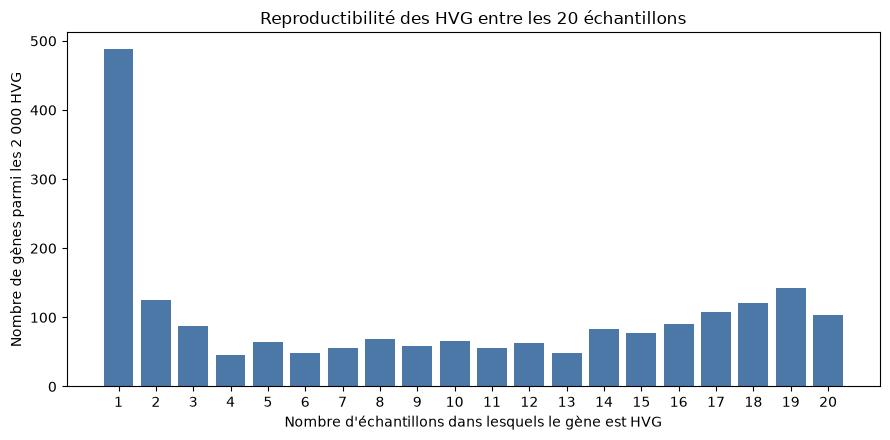

In [5]:
hvg_nbatches = adata.var.loc[adata.var["highly_variable"], "highly_variable_nbatches"].astype(int)
nbatches_distribution = (
    hvg_nbatches.value_counts().reindex(range(1, 21), fill_value=0)
    .rename_axis("n_samples").rename("n_hvg").reset_index()
)
display(nbatches_distribution)
q1, median_nbatches, q3 = hvg_nbatches.quantile([0.25, 0.50, 0.75])
reproducibility_summary = pd.Series({
    "Q1_highly_variable_nbatches": q1,
    "median_highly_variable_nbatches": median_nbatches,
    "Q3_highly_variable_nbatches": q3,
    "HVG_in_at_least_5_samples": int((hvg_nbatches >= 5).sum()),
    "HVG_in_at_least_10_samples": int((hvg_nbatches >= 10).sum()),
    "HVG_in_at_least_15_samples": int((hvg_nbatches >= 15).sum()),
    "HVG_in_all_20_samples": int((hvg_nbatches == 20).sum()),
}, name="value")
display(reproducibility_summary.to_frame())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(nbatches_distribution["n_samples"], nbatches_distribution["n_hvg"], color="#4C78A8")
ax.set_xticks(range(1, 21))
ax.set_xlabel("Nombre d'échantillons dans lesquels le gène est HVG")
ax.set_ylabel("Nombre de gènes parmi les 2 000 HVG")
ax.set_title("Reproductibilité des HVG entre les 20 échantillons")
fig.tight_layout()
fig.savefig(figure_dir / "hvg_nbatches_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Graphique standard de sélection HVG

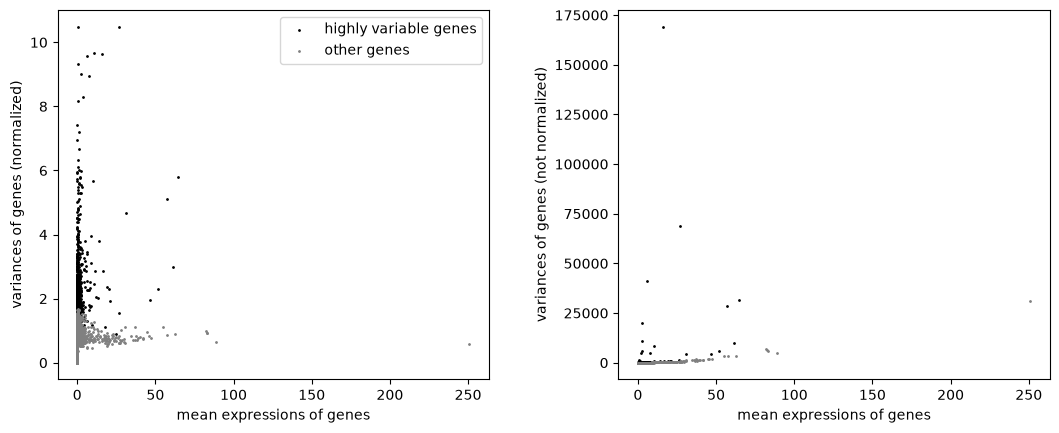

In [6]:
sc.pl.highly_variable_genes(adata, show=False)
hvg_figure = plt.gcf()
hvg_figure.savefig(figure_dir / "hvg_selection_seurat_v3.png", dpi=300, bbox_inches="tight")
plt.show()

## Résumé descriptif

In [7]:
display(Markdown(
    f"**2 000 HVG** ont été sélectionnés sur les counts bruts avec seurat_v3, en tenant compte des 20 échantillons. "
    f"Le nombre médian d'échantillons dans lesquels un HVG est retrouvé est **{median_nbatches:.1f}** "
    f"(Q1 = **{q1:.1f}**, Q3 = **{q3:.1f}**). "
    f"Parmi eux, **{int((hvg_nbatches >= 5).sum())}** sont retrouvés dans au moins 5 échantillons, "
    f"**{int((hvg_nbatches >= 10).sum())}** dans au moins 10, "
    f"**{int((hvg_nbatches >= 15).sum())}** dans au moins 15 et "
    f"**{int((hvg_nbatches == 20).sum())}** dans les 20 échantillons. "
    "Aucune normalisation, réduction dimensionnelle ou sélection physique des seuls HVG n'a été effectuée."
))

**2 000 HVG** ont été sélectionnés sur les counts bruts avec seurat_v3, en tenant compte des 20 échantillons. Le nombre médian d'échantillons dans lesquels un HVG est retrouvé est **9.0** (Q1 = **2.0**, Q3 = **16.0**). Parmi eux, **1254** sont retrouvés dans au moins 5 échantillons, **960** dans au moins 10, **644** dans au moins 15 et **103** dans les 20 échantillons. Aucune normalisation, réduction dimensionnelle ou sélection physique des seuls HVG n'a été effectuée.

## Comparison with seurat_v3_paper

In [8]:
main_hvg_before = adata.var["highly_variable"].copy()
adata_hvg_paper = adata.copy()

sc.pp.highly_variable_genes(
    adata_hvg_paper,
    n_top_genes=2000,
    flavor="seurat_v3_paper",
    batch_key="sample_id",
    layer="counts",
    inplace=True,
)

hvg_v3 = set(adata.var_names[adata.var["highly_variable"]])
hvg_paper = set(adata_hvg_paper.var_names[adata_hvg_paper.var["highly_variable"]])
hvg_common = hvg_v3 & hvg_paper
hvg_only_v3 = hvg_v3 - hvg_paper
hvg_only_paper = hvg_paper - hvg_v3
overlap_pct = 100 * len(hvg_common) / 2000

overlap_summary = pd.Series({
    "HVG_common": len(hvg_common),
    "only_seurat_v3": len(hvg_only_v3),
    "only_seurat_v3_paper": len(hvg_only_paper),
    "overlap_percent_of_2000": overlap_pct,
}, name="value")
display(overlap_summary.to_frame())

if not adata.var["highly_variable"].equals(main_hvg_before):
    raise AssertionError("La sélection principale seurat_v3 dans adata a été modifiée.")
print("Sélection principale seurat_v3 inchangée : True")

,value
HVG_common,1142.0
only_seurat_v3,858.0
only_seurat_v3_paper,858.0
overlap_percent_of_2000,57.1


Sélection principale seurat_v3 inchangée : True


,n_samples,n_hvg
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
5,6,0
6,7,175
7,8,219
8,9,175
9,10,179


,Q1,median,Q3,exactly_1_sample,at_least_5_samples,at_least_10_samples,at_least_15_samples,all_20_samples
method,,,,,,,,
seurat_v3,2.0,9.0,16.0,488,1254,960,644,103
seurat_v3_paper,9.0,12.0,17.0,0,2000,1431,743,105


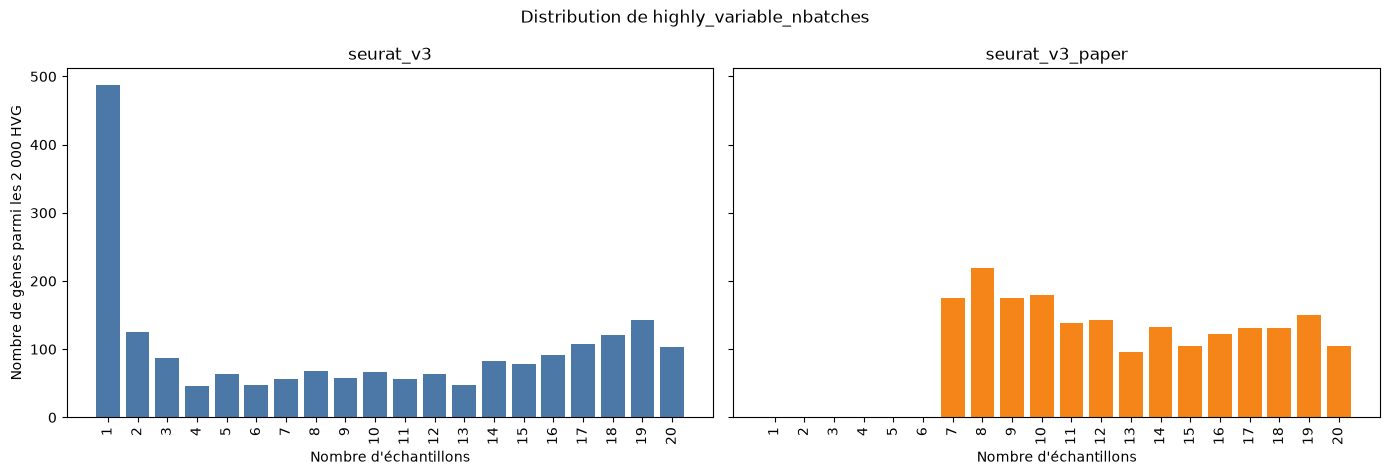

20 premiers gènes uniquement seurat_v3 :


,gene_name,highly_variable_rank,highly_variable_nbatches
0,PI3,25.0,1
1,DNAJB1,65.0,1
2,IGLV3-19,170.0,2
3,HBG1,175.5,6
4,IGHV6-1,196.0,3
5,AC080013.5,234.0,1
6,GJB2,237.0,1
7,MOB3C,259.0,2
8,IGHV3-66,269.0,1
9,IGHV3-72,299.5,2


20 premiers gènes uniquement seurat_v3_paper :


,gene_name,highly_variable_rank,highly_variable_nbatches
0,SECTM1,926.5,18
1,FCGR1A,928.0,15
2,PKHD1L1,928.0,7
3,TRIM58,929.5,12
4,ADAM28,930.0,19
5,ITGB3BP,930.0,8
6,PHLDA1,931.5,14
7,FRMD4B,932.0,13
8,DYNLL1,932.0,10
9,TMPO,933.0,13


In [9]:
hvg_nbatches_paper = adata_hvg_paper.var.loc[
    adata_hvg_paper.var["highly_variable"], "highly_variable_nbatches"
].astype(int)
nbatches_distribution_paper = (
    hvg_nbatches_paper.value_counts().reindex(range(1, 21), fill_value=0)
    .rename_axis("n_samples").rename("n_hvg").reset_index()
)
display(nbatches_distribution_paper)

def summarize_nbatches(values):
    q1_value, median_value, q3_value = values.quantile([0.25, 0.50, 0.75])
    return {
        "Q1": q1_value,
        "median": median_value,
        "Q3": q3_value,
        "exactly_1_sample": int((values == 1).sum()),
        "at_least_5_samples": int((values >= 5).sum()),
        "at_least_10_samples": int((values >= 10).sum()),
        "at_least_15_samples": int((values >= 15).sum()),
        "all_20_samples": int((values == 20).sum()),
    }

method_comparison = pd.DataFrame.from_dict({
    "seurat_v3": summarize_nbatches(hvg_nbatches),
    "seurat_v3_paper": summarize_nbatches(hvg_nbatches_paper),
}, orient="index").rename_axis("method")
display(method_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True, sharey=True)
for ax, distribution, title, color in [
    (axes[0], nbatches_distribution, "seurat_v3", "#4C78A8"),
    (axes[1], nbatches_distribution_paper, "seurat_v3_paper", "#F58518"),
]:
    ax.bar(distribution["n_samples"], distribution["n_hvg"], color=color)
    ax.set_title(title)
    ax.set_xlabel("Nombre d'échantillons")
    ax.set_xticks(range(1, 21))
    ax.tick_params(axis="x", labelrotation=90)
axes[0].set_ylabel("Nombre de gènes parmi les 2 000 HVG")
fig.suptitle("Distribution de highly_variable_nbatches")
fig.tight_layout()
fig.savefig(figure_dir / "hvg_nbatches_seurat_v3_vs_paper.png", dpi=300, bbox_inches="tight")
plt.show()

only_v3_top20 = (
    adata.var.loc[list(hvg_only_v3), ["highly_variable_rank", "highly_variable_nbatches"]]
    .sort_values("highly_variable_rank").head(20)
    .rename_axis("gene_name").reset_index()
)
only_paper_top20 = (
    adata_hvg_paper.var.loc[list(hvg_only_paper), ["highly_variable_rank", "highly_variable_nbatches"]]
    .sort_values("highly_variable_rank").head(20)
    .rename_axis("gene_name").reset_index()
)
print("20 premiers gènes uniquement seurat_v3 :")
display(only_v3_top20)
print("20 premiers gènes uniquement seurat_v3_paper :")
display(only_paper_top20)

## Final HVG selection

In [10]:
paper_hvg_expected = adata_hvg_paper.var["highly_variable"].copy()
n_obs_before_final_hvg = adata.n_obs
n_vars_before_final_hvg = adata.n_vars

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3_paper",
    batch_key="sample_id",
    layer="counts",
    inplace=True,
)

x_sparse = sparse.issparse(adata.X)
counts_layer_sparse = sparse.issparse(adata.layers["counts"])
if not x_sparse or not counts_layer_sparse:
    raise AssertionError("adata.X et adata.layers['counts'] doivent rester sparse.")

x_data = adata.X.data
counts_layer_data = adata.layers["counts"].data
x_matches_counts_layer = (adata.X != adata.layers["counts"]).nnz == 0
final_hvg_checks = {
    "exactly_2000_HVG": int(adata.var["highly_variable"].sum()) == 2000,
    "matches_previous_seurat_v3_paper_selection": adata.var["highly_variable"].equals(paper_hvg_expected),
    "58825_cells_unchanged": adata.n_obs == n_obs_before_final_hvg == 58825,
    "33538_genes_retained": adata.n_vars == n_vars_before_final_hvg == 33538,
    "X_sparse_raw_counts": x_sparse and bool(np.all(x_data >= 0)) and bool(np.all(np.equal(x_data, np.floor(x_data)))),
    "counts_layer_sparse_raw_counts": counts_layer_sparse and bool(np.all(counts_layer_data >= 0)) and bool(np.all(np.equal(counts_layer_data, np.floor(counts_layer_data)))),
    "X_identical_to_counts_layer": x_matches_counts_layer,
    "no_log1p_metadata": "log1p" not in adata.uns,
}
display(pd.Series(final_hvg_checks, name="passed").to_frame())
if not all(final_hvg_checks.values()):
    raise AssertionError(f"Échec des contrôles de sélection HVG finale : {final_hvg_checks}")

print("Méthode HVG finale : seurat_v3_paper")
print("Nombre de HVG :", int(adata.var["highly_variable"].sum()))
print("Dimensions finales :", adata.shape)
print("Tous les gènes sont conservés :", adata.n_vars == 33538)

,passed
exactly_2000_HVG,True
matches_previous_seurat_v3_paper_selection,True
58825_cells_unchanged,True
33538_genes_retained,True
X_sparse_raw_counts,True
counts_layer_sparse_raw_counts,True
X_identical_to_counts_layer,True
no_log1p_metadata,True


Méthode HVG finale : seurat_v3_paper
Nombre de HVG : 2000
Dimensions finales : (58825, 33538)
Tous les gènes sont conservés : True


Les méthodes seurat_v3 et seurat_v3_paper ont été comparées : leur overlap était de 1 142/2 000 (57,1 %). seurat_v3 retenait 488 HVG présents dans un seul échantillon, tandis que seurat_v3_paper ne retenait aucun HVG présent dans moins de 7 échantillons. seurat_v3_paper a donc été retenu pour construire un espace cellulaire global plus robuste aux particularités individuelles. Tous les gènes restent conservés pour les analyses ultérieures.